## Modello TransferMobileNet

# 1. Introduzione del problema

Il settore agricolo subisce ogni anno ingenti perdite economiche a causa delle malattie delle piante. L'identificazione tempestiva e accurata di queste patologie è fondamentale per intervenire preventivamente e salvare i raccolti.
L'obiettivo di questo progetto è sviluppare un modello capace di classificare autonomamente lo stato di salute di una foglia (sana o malata) partendo da un'immagine, automatizzando così un processo che richiederebbe la supervisione di un esperto.

# 2. Descrizione del dataset

Per l'addestramento del modello è stato utilizzato un sottoinsieme specifico del dataset pubblico **PlantVillage**. I dati originali sono organizzati in cartelle, dove ogni singola directory rappresenta una specifica combinazione di "tipo di pianta" e "malattia".

Il dataset analizzato è composto da un totale di **13 classi**, riguardanti tre tipologie di colture agricole: **Peperone (Pepper bell)**, **Patata (Potato)** e **Pomodoro (Tomato)**.

Dal punto di vista visivo, le immagini sono fortemente standardizzate: presentano l'inquadratura ravvicinata di una singola foglia posta su uno sfondo neutro e uniforme. Questa similarità e pulizia tra gli scatti rappresenta un vantaggio cruciale per il task di classificazione, in quanto permette alla rete neurale di concentrarsi esclusivamente sui pattern visivi della patologia (macchie, accartocciamenti) senza essere ingannata da elementi di disturbo o sfondi caotici esterni.

Importazione librerie

In [1]:
import os
import json
import torch
from torch.utils.tensorboard import SummaryWriter
from utils import rinomina_classi_in_dir, undersample_dataset, count_images_per_class, split_train_val_test
from data_loader import get_data_loaders
from model import TransferMobileNet
from train import train_model
from evaluate import evaluate_model, plot_training, plot_distribution, visualize_sample_images, plot_leaf_type_pie_chart
from jsonschema import validate
import jsonschema

Matplotlib is building the font cache; this may take a moment.


# 3. Lettura e preparazione dei dati

A partire dai dati grezzi contenuti nella cartella originale `PlantVillage`, è stata eseguita una pipeline di preparazione essenziale per il corretto addestramento del modello. Come evidenziato dalla struttura delle directory del progetto, i dati sono stati elaborati in due step che hanno generato due nuove cartelle:

**Bilanciamento (`PlantVillage_balanced`):** Le classi originali presentavano un numero di immagini eterogeneo. Per evitare che il modello sviluppasse un bias verso le malattie con più campioni (le classi maggioritarie), il dataset è stato bilanciato, salvando il risultato in questa directory dedicata.

**Data Split (`PlantVillage_split`):** Per garantire una corretta valutazione ed evitare il fenomeno del data leakage, il dataset bilanciato è stato suddiviso in tre sottoinsiemi distinti all'interno di questa cartella:
   * **Training Set:** Usato per l'addestramento vero e proprio (con aggiornamento dei pesi).
   * **Validation Set (15%):** Usato per monitorare le performance epoca per epoca ed evitare l'overfitting.
   * **Test Set (15%):** Usato esclusivamente alla fine per testare il modello su dati mai visti.

Tutti i parametri di configurazione (path delle cartelle, learning rate, batch size) vengono gestiti dinamicamente tramite un file `config.json`.

Caricamento del config.json

In [2]:
#Caricamento del Config
with open('config_mobilenet.json', 'r') as f:
    config = json.load(f)

In [3]:
# Caricamento del JSON Schema
with open('config.schema.json', 'r') as f:
    schema = json.load(f)

# Validazione della configurazione
try:
    validate(instance=config, schema=schema)
    print("Configurazione valida.")
except jsonschema.exceptions.ValidationError as err:
    print("Errore nella configurazione:", err)
    raise


Configurazione valida.


Configurazione modello e organizzazione cartelle

In [4]:
# Configurazione
original_dir = config.get("original_data_path", "./Dataset/PlantVillage")
balanced_dir = config.get("balanced_data_path", "./Dataset/PlantVillage_balanced")
split_dir = config.get("split_data_path", "./Dataset/PlantVillage_split")

train_dir = config["train_data_path"]  
val_dir = config["val_data_path"]      
test_dir = config["test_data_path"]    

batch_size = config.get("batch_size", 32)
val_ratio = 0.15     
test_ratio = 0.15      
epochs = config.get("num_epochs", 5)
learning_rate = config.get("learning_rate", 0.001)
target_accuracy = config.get("target_accuracy", 0.95)
early_stopping_patience = config.get("early_stopping_patience", 3)

print(f"Original data dir: {original_dir}")
print(f"Balanced data dir: {balanced_dir}")
print(f"Split data dir: {split_dir}")
print(f"Training dir (loader): {train_dir}")
print(f"Validation dir (loader): {val_dir}")


Original data dir: ./Dataset/PlantVillage
Balanced data dir: ./Dataset/PlantVillage_balanced
Split data dir: ./Dataset/PlantVillage_split
Training dir (loader): ./Dataset/PlantVillage_split/train
Validation dir (loader): ./Dataset/PlantVillage_split/val


# 4. Visualizzazione ed Analisi Esplorativa dei Dati

Prima di procedere con la fase di addestramento, è fondamentale esplorare visivamente il dataset. L'Analisi Esplorativa dei dati ci permette di:
1. Confermare la corretta esecuzione del bilanciamento, verificando che tutte e 13 le classi abbiano una distribuzione uniforme.
2. Rinomainare le classi in modo tale da avere più ordine e maggiore leggibilità.
3. Ispezionare visivamente i campioni reali di foglie di peperone, patata e pomodoro con cui la rete neurale dovrà lavorare.

Di seguito vengono generati un grafico a torta per le tipologie di piante, l'istogramma della distribuzione delle classi e una griglia di immagini di esempio estratte dal dataset.

Esposizione Immagini del DataSet

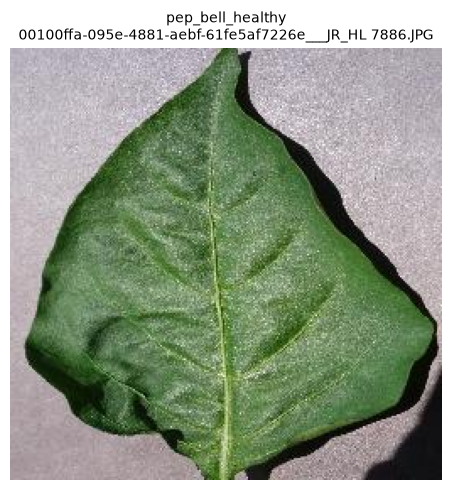

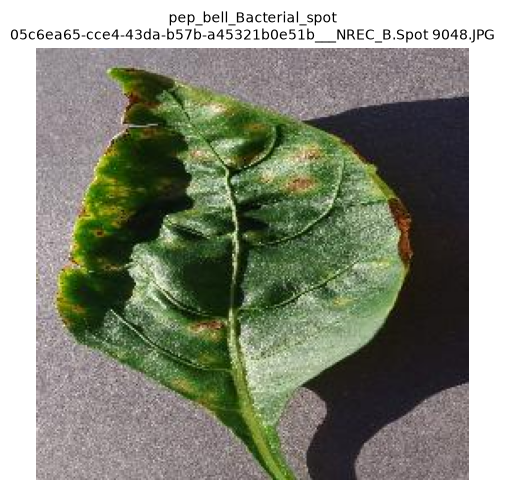

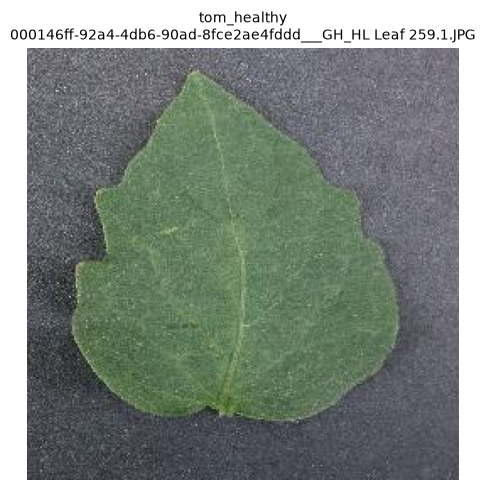

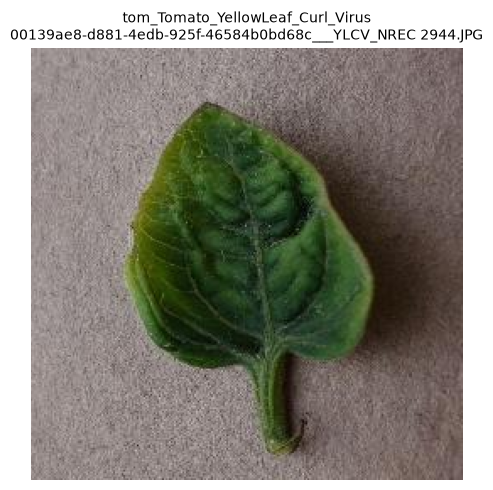

In [5]:
# Visualizzazione immagini di foglie malate e foglie sane

visualize_sample_images('./Dataset/PlantVillage', class_name='pep_bell_healthy', num_images=1)
visualize_sample_images('./Dataset/PlantVillage', class_name='pep_bell_Bacterial_spot', num_images=1)


visualize_sample_images('./Dataset/PlantVillage', class_name='tom_healthy', num_images=1)
visualize_sample_images('./Dataset/PlantVillage', class_name='tom_Tomato_YellowLeaf_Curl_Virus', num_images=1)


Rinominazione delle classi e bilanciamento del DataSet

In [6]:
# Rinomina classi
rinomina_classi_in_dir(original_dir)

In [7]:
# Undersampling per bilanciare
undersample_dataset(original_dir, balanced_dir, max_per_class=1000)

✅ Dataset ridotto salvato in: ./Dataset/PlantVillage_balanced


Distribuzione originale: {'pep_bell_Bacterial_spot': 976, 'pep_bell_healthy': 1478, 'pot_Early_blight': 1000, 'pot_Late_blight': 1000, 'tom_Bacterial_spot': 2127, 'tom_Early_blight': 1000, 'tom_healthy': 1591, 'tom_Late_blight': 1909, 'tom_Leaf_Mold': 952, 'tom_Septoria_leaf_spot': 1771, 'tom_Spider_mites_Two_spotted_spider_mite': 1676, 'tom_Target_Spot': 1404, 'tom_Tomato_YellowLeaf_Curl_Virus': 3208}
Distribuzione bilanciata: {'pep_bell_Bacterial_spot': 976, 'pep_bell_healthy': 1000, 'pot_Early_blight': 1000, 'pot_Late_blight': 1000, 'tom_Bacterial_spot': 1000, 'tom_Early_blight': 1000, 'tom_healthy': 1000, 'tom_Late_blight': 1000, 'tom_Leaf_Mold': 952, 'tom_Septoria_leaf_spot': 1000, 'tom_Spider_mites_Two_spotted_spider_mite': 1000, 'tom_Target_Spot': 1000, 'tom_Tomato_YellowLeaf_Curl_Virus': 1000}


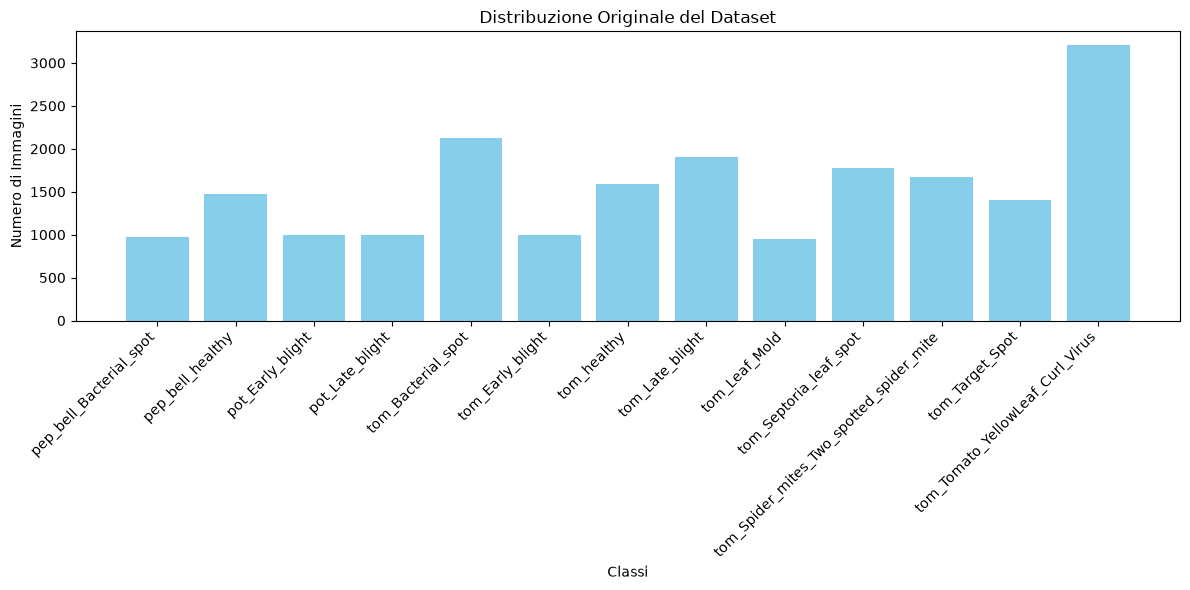

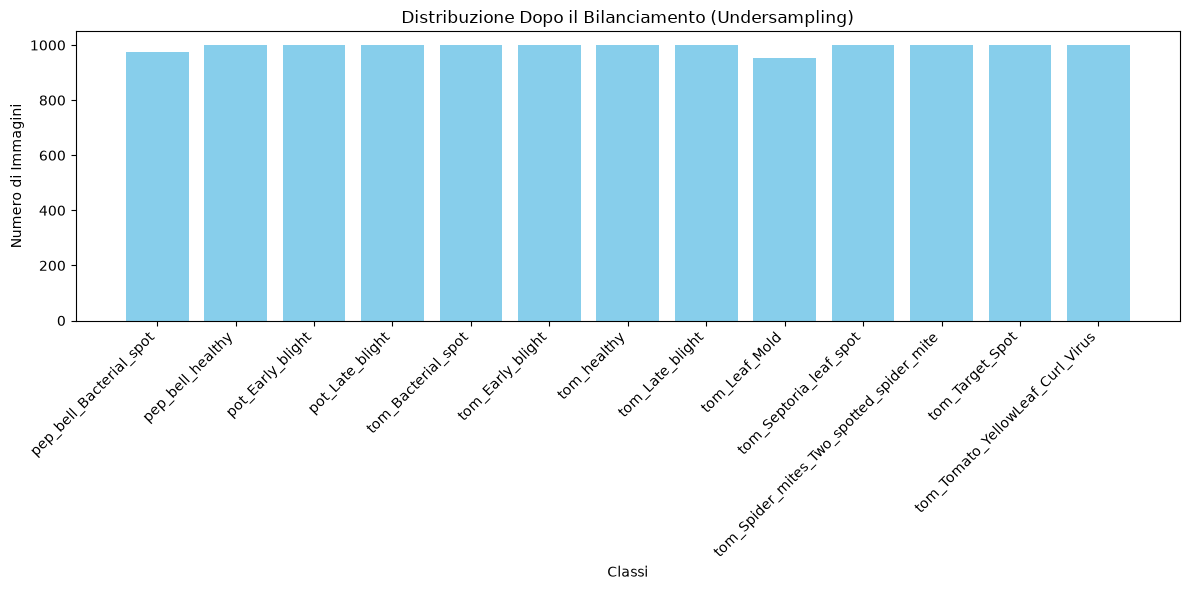

In [8]:
# Conta immagini e salva le distribuzioni
original_distribution = count_images_per_class(original_dir)
balanced_distribution = count_images_per_class(balanced_dir)
# Stampa conteggi
print("Distribuzione originale:", original_distribution)
print("Distribuzione bilanciata:", balanced_distribution)
# Visualizza distribuzioni
plot_distribution(original_distribution, "Distribuzione Originale del Dataset")
plot_distribution(balanced_distribution, "Distribuzione Dopo il Bilanciamento (Undersampling)")

Grafico a Torta

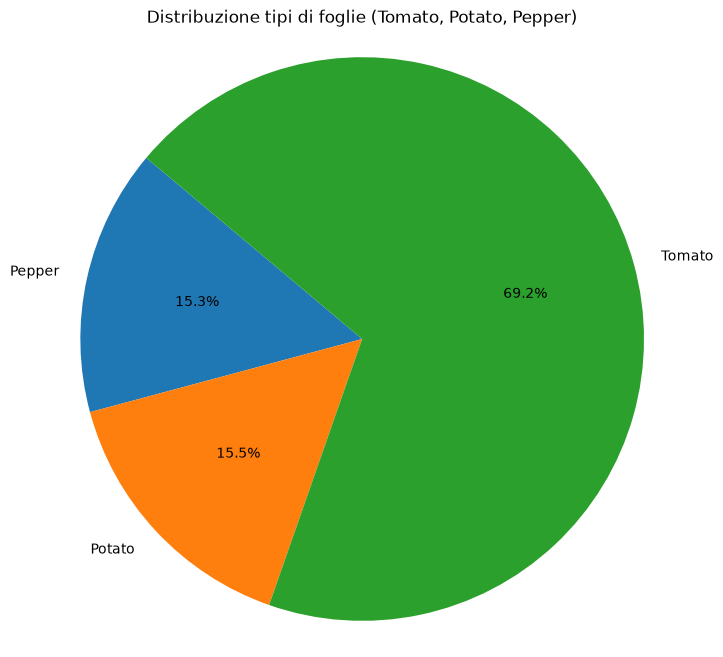

In [9]:
plot_leaf_type_pie_chart("DataSet/PlantVillage_split/train")

In [10]:
# Split train/val/test
split_train_val_test(balanced_dir, split_dir, val_ratio=val_ratio, test_ratio=test_ratio)
print("Dataset splittato in train/val/test.")

Dataset splittato in train/val/test.


## 5. Preprocessing

La fase di preprocessing si è concentrata quindi sulla trasformazione dei tensori e sulla **Data Augmentation**, implementate all'interno del modulo `data_loader.py` e applicate da `augmentation.py`.

Per migliorare la capacità di generalizzazione del modello e prevenire l'overfitting, applichiamo due pipeline di trasformazione distinte:

**1. Training Set (Data Augmentation attiva):**
Durante l'addestramento, le immagini vengono modificate dinamicamente per mostrare al modello scenari sempre nuovi:
* **RandomResizedCrop:** Le immagini vengono ritagliate e ridimensionate alla risoluzione operativa di 128x128 pixel.
* **RandomHorizontalFlip & RandomRotation(20):** Specchiatura orizzontale e rotazione casuale (fino a 20 gradi) per rendere il modello invariante all'orientamento della foglia.
* **ColorJitter:** Variazioni casuali di luminosità, contrasto e saturazione (fattore 0.1) per simulare diverse condizioni di luce sul campo agricolo.
* **ToTensor & Normalize:** Conversione in tensore PyTorch e normalizzazione basata sui parametri di ImageNet.

**2. Validation / Test Set (Nessuna distorsione):**
Sui dati di validazione e test non viene applicata alcuna distorsione visiva. Le immagini subiscono unicamente un ridimensionamento a 128x128, la conversione in tensore e la standardizzazione, in modo da valutare il modello su campioni perfettamente integri.

In [11]:
# DataLoader
train_loader, val_loader, test_loader, class_names = get_data_loaders(split_dir, img_size=(128, 128), batch_size=batch_size)
print(f"Classi: {class_names}")

Classi: ['pep_bell_Bacterial_spot', 'pep_bell_healthy', 'pot_Early_blight', 'pot_Late_blight', 'tom_Bacterial_spot', 'tom_Early_blight', 'tom_Late_blight', 'tom_Leaf_Mold', 'tom_Septoria_leaf_spot', 'tom_Spider_mites_Two_spotted_spider_mite', 'tom_Target_Spot', 'tom_Tomato_YellowLeaf_Curl_Virus', 'tom_healthy']


## 6. Implementazione del modello MobileNet

Per affrontare questo task di classificazione multiclasse, l'architettura principale scelta è **MobileNet**. A differenza delle tradizionali Reti Neurali Convoluzionali, MobileNet utilizza convoluzioni *Depthwise Separable*, riducendo drasticamente il numero di parametri e la potenza di calcolo richiesta. È un modello leggero, ideale per futuri impieghi su dispositivi edge. 

Su questa architettura abbiamo applicato il **Transfer Learning**:
* Lo scheletro della rete utilizza i pesi pre-addestrati su ImageNet (ottimi per riconoscere feature visive di base).
* L'ultimo strato (Fully Connected layer) è stato sostituito con un classificatore lineare impostato per le **13 classi** di PlantVillage.

**Il modello di Baseline (CustomCNN)**
Per evidenziare i vantaggi del Transfer Learning e avere un solido termine di paragone, all'interno di un notebook parallelo è stata implementata e addestrata da zero una rete convoluzionale personalizzata (**CustomCNN**). Questo ci permetterà di valutare l'effettivo "salto" prestazionale e i tempi di convergenza garantiti dall'uso di una rete pre-addestrata rispetto a una rete creata da zero.

Creazione del Modello e scelta device

In [12]:
# Creazione modello e device

model = TransferMobileNet(num_classes=len(class_names)) #CustomCNN(num_classes=len(class_names))
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
model = model.to(device)

Using device: cpu


## 7. Valutazione e confronto dei risultati

In questa fase avviamo l'addestramento del modello e ne valutiamo le performance finali. Per garantire una convergenza stabile e ottimizzare i tempi di calcolo, la funzione di training (definita in `train.py`) implementa diverse tecniche avanzate:

1. **ReduceLROnPlateau:** Il learning rate viene ridotto dinamicamente se la *Validation Loss* smette di scendere.
2. **Early Stopping:** L'addestramento viene interrotto in anticipo se il modello non migliora sui dati di validazione per un numero predefinito di epoche(3), prevenendo così l'overfitting.
3. **Checkpointing:** Viene salvato su disco il modello migliore (`model_best.pth`) basato sulla Validation Accuracy.

Al termine dell'addestramento, caricheremo i pesi del modello migliore e lo valuteremo sul **Test Set** (dati mai visti dalla rete). Infine, confronteremo l'approccio **TransferMobileNet** con la nostra baseline **CustomCNN** (sviluppata nel notebook parallelo) analizzando le curve di apprendimento e la Confusion Matrix.

Training e andamento training

In [13]:
# Chiamata Training
print("=== AVVIO ADDESTRAMENTO ===")
# Addestramento del modello usando Train e Validation Set
model, train_losses, val_losses, train_accs, val_accs = train_model(
    model=model, 
    train_loader=train_loader, 
    val_loader=val_loader, 
    device=device, 
    epochs=epochs,
    lr=learning_rate,
    early_stopping_patience=early_stopping_patience,
    target_accuracy=target_accuracy,
    checkpoint_dir=config.get("checkpoint_dir", "./checkpoints"),
    resume_from=None, #'checkpoints\model_best.pth',
    log_dir=config.get("log_dir", "./runs/MobileNet")
)


#tensorboard --logdir=./runs/MobileNet

=== AVVIO ADDESTRAMENTO ===
Epoch 1/5 - Train loss: 0.8943, Train acc: 0.7029 - Val loss: 0.5468, Val acc: 0.8127
Epoch 2/5 - Train loss: 0.6632, Train acc: 0.7806 - Val loss: 0.6265, Val acc: 0.8153
Epoch 3/5 - Train loss: 0.5589, Train acc: 0.8164 - Val loss: 0.3713, Val acc: 0.8720
Epoch 4/5 - Train loss: 0.4866, Train acc: 0.8417 - Val loss: 0.3237, Val acc: 0.8875
Epoch 5/5 - Train loss: 0.4755, Train acc: 0.8425 - Val loss: 0.3752, Val acc: 0.8803


In [14]:
# Caricamento modello migliore durante il training
checkpoint_path = os.path.join("./checkpoints", 'model_best.pth')
if os.path.exists(checkpoint_path):
    model.load_state_dict(torch.load(checkpoint_path)['model_state_dict'])
    print(f"\nCaricato il modello migliore da {checkpoint_path}")


Caricato il modello migliore da ./checkpoints\model_best.pth


Curva di apprendimento

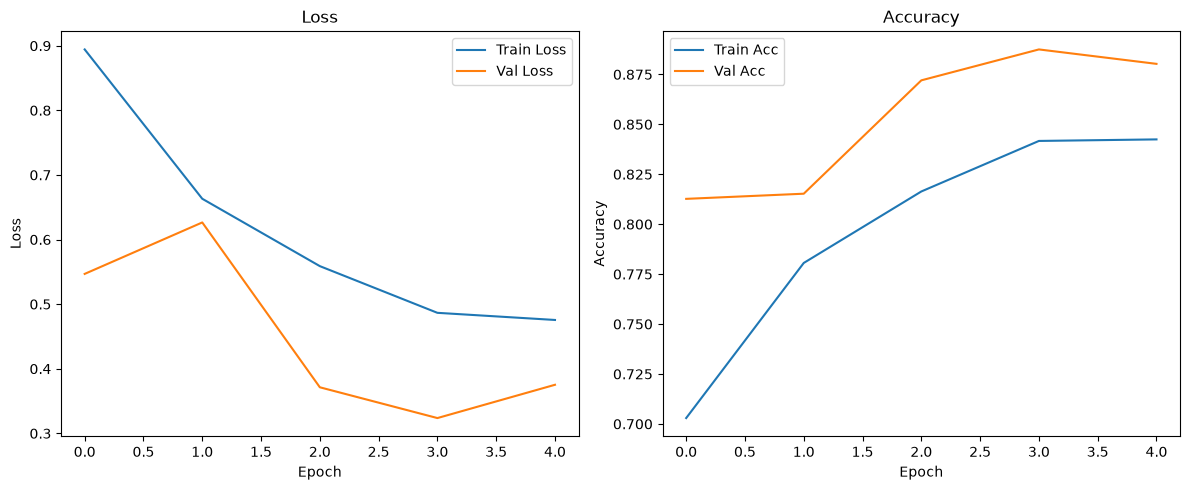

In [15]:
# Visualizza andamento training
plot_training(train_losses, val_losses, train_accs, val_accs)

Valutazione Modello

 Tempo di Inferenza totale sul set: 64.24 secondi
 Tempo medio per batch: 1.0531 secondi
------------------------------
Classification Report:
                                          precision    recall  f1-score   support

                 pep_bell_Bacterial_spot       0.92      0.97      0.94       146
                        pep_bell_healthy       0.99      0.98      0.98       150
                        pot_Early_blight       0.99      0.99      0.99       150
                         pot_Late_blight       1.00      0.87      0.93       150
                      tom_Bacterial_spot       0.97      0.81      0.88       150
                        tom_Early_blight       0.92      0.67      0.78       150
                         tom_Late_blight       0.74      0.96      0.84       150
                           tom_Leaf_Mold       0.95      0.94      0.94       142
                  tom_Septoria_leaf_spot       0.90      0.86      0.88       150
tom_Spider_mites_Two_spotted_spider_

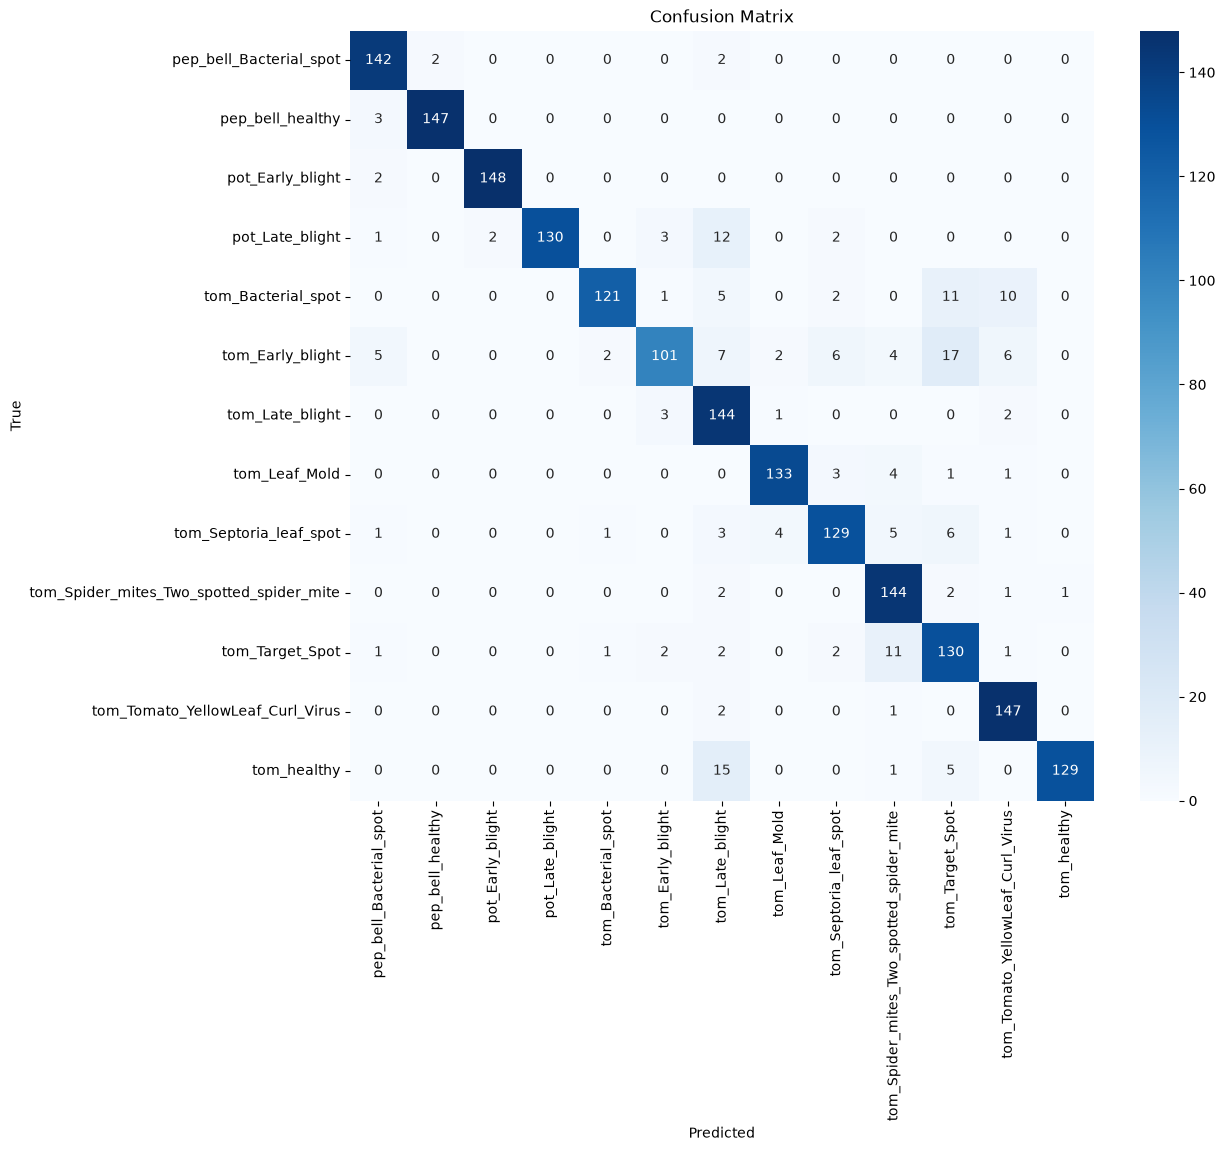

In [16]:
# Valuta il modello su test set
evaluate_model(model, test_loader, device, class_names)

**Analisi dei risultati e Confronto:** 

* **Curve di apprendimento e Convergenza:** Come visibile dai grafici generati, il comportamento del modello è eccellente. A differenza della *CustomCNN* (che mostrava segni di overfitting già alla quarta epoca), qui la *Validation Loss*, dopo un breve innalzamento scende in modo costante e lineare, mentre l'accuratezza sale oltre fino al 88%. Questo dimostra la potenza dei pesi pre-addestrati, la rete parte già con un'ottima capacità di estrazione delle feature spaziali.
* **Tempi di Inferenza:** L'architettura MobileNet si dimostra non solo più precisa, ma anche più efficiente della nostra baseline abbassando il tempo medio di inferenza a **1.0531 secondi per batch**.
* **Metriche (Classification Report):** L'accuratezza globale compie un balzo enorme, passando dal 70% della baseline al 90%. Il modello riconosce perfettamente le foglie sane (come `pep_bell_healthy`, Precision 0.99) e identifica con precisione assoluta `pot_Late_blight` (Precision 1.00).

**Analisi critica degli errori:**
Nonostante le ottime performance, il modello presenta una specifica area di incertezza fisiologica:
* **Difficoltà e bassi valori di Recall su `tom_Early_blight`:** Questa classe presenta una Recall particolarmente bassa (0.67), indicando che il modello non riesce a individuare correttamente circa un terzo dei campioni reali di questa infezione, confondendoli probabilmente con altre patologie fogliari simili.
* **Falsi Positivi su `tom_Late_blight`:** La classe presenta una *Recall* altissima (0.96) ma una *Precision* più bassa (0.74). Questo indica che il modello è estremamente cauto: quasi non si perde mai una foglia affetta da peronospora tardiva, ma tende a "sovrastimare" il problema, classificando come `Late_blight` anche lesioni fogliari appartenenti ad altre patologie.

Salvataggio del modello

In [17]:
# Salvataggio Modello finale
torch.save(model.state_dict(), "plantvillage_transfer_model.pth")
print("✅ Modello salvato in plantvillage_transfer_model.pth")

✅ Modello salvato in plantvillage_transfer_model.pth


## 8. Conclusioni finali

Questo progetto ha affrontato il complesso problema della classificazione automatica delle malattie fogliari in ambito agricolo, utilizzando il dataset PlantVillage. L'obiettivo era dimostrare l'efficacia del Deep Learning, e in particolare del **Transfer Learning**, per l'analisi di immagini in contesti applicativi reali.

L'implementazione modulare della pipeline di preprocessing, combinata con tecniche di ottimizzazione avanzate (Early Stopping, ReduceLROnPlateau, Checkpointing), ha garantito un addestramento robusto e riproducibile. 

Il confronto tra i due esperimenti condotti ha restituito un responso netto:
1. **La Baseline (CustomCNN):** Addestrare un'architettura da zero su questo dataset ha portato a un'accuratezza del **70%**, mostrando evidenti limiti nell'estrazione delle feature e una forte tendenza all'overfitting.
2. **Transfer Learning (MobileNetV2):** Sfruttando i filtri estrattori pre-addestrati su ImageNet, il modello ha raggiunto il **90% di accuratezza sul Test** in sole 5 epoche, dimostrandosi al contempo più veloce nell'inferenza grazie all'uso delle *Depthwise Separable Convolutions*.

**Sviluppi futuri:**
Per mitigare i falsi positivi riscontrati su specifiche patologie visivamente simili, i futuri sviluppi potrebbero integrare una funzione di *Focal Loss* per penalizzare gli errori sulle classi più ambigue, oppure l'introduzione di un modulo di *Object Detection* per isolare preventivamente l'area lesionata dal resto del fogliame.